In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

In [2]:
SAheart_df = pd.read_csv("DATA/SAheart.csv")

In [3]:
SAheart_df.head()

,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd
0,160,12.00,5.73,23.11,Present,49,25.30,97.20,52,Si
1,144,0.01,4.41,28.61,Absent,55,28.87,2.06,63,Si
2,118,0.08,3.48,32.28,Present,52,29.14,3.81,46,No
3,170,7.50,6.41,38.03,Present,51,31.99,24.26,58,Si
4,134,13.60,3.50,27.78,Present,60,25.99,57.34,49,Si


In [4]:
SAheart_df.columns

Index(['sbp', 'tobacco', 'ldl', 'adiposity', 'famhist', 'typea', 'obesity',
       'alcohol', 'age', 'chd'],
      dtype='str')

In [5]:
SAheart_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sbp        462 non-null    int64  
 1   tobacco    462 non-null    float64
 2   ldl        462 non-null    float64
 3   adiposity  462 non-null    float64
 4   famhist    462 non-null    str    
 5   typea      462 non-null    int64  
 6   obesity    462 non-null    float64
 7   alcohol    462 non-null    float64
 8   age        462 non-null    int64  
 9   chd        462 non-null    str    
dtypes: float64(5), int64(3), str(2)
memory usage: 40.0 KB


Q.1 How many records are present in the dataset? print the metadata info of the dataset.

In [6]:
SAheart_df.shape[0]

462

Q.2 Draw a bar plot to show the no. of persons having CHD or not in comparison to they having family history of the disease or not?

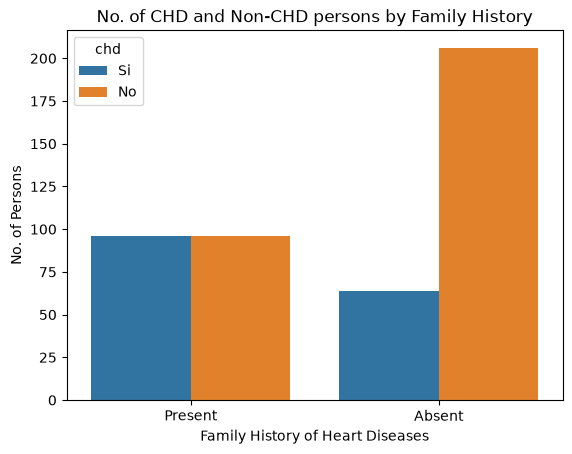

In [7]:
sn.countplot(data= SAheart_df,
            x='famhist',hue='chd')
plt.xlabel('Family History of Heart Diseases')
plt.ylabel('No. of Persons')
plt.title('No. of CHD and Non-CHD persons by Family History')
plt.show()

In [8]:
SAheart_df['famhist'].unique()

<ArrowStringArray>
['Present', 'Absent']
Length: 2, dtype: str

In [9]:
SAheart_df['chd'].unique()

<ArrowStringArray>
['Si', 'No']
Length: 2, dtype: str

In [10]:
SAheart_df['sbp'].corr(SAheart_df['age'])

np.float64(0.3887705972765735)

In [11]:
SAheart_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sbp        462 non-null    int64  
 1   tobacco    462 non-null    float64
 2   ldl        462 non-null    float64
 3   adiposity  462 non-null    float64
 4   famhist    462 non-null    str    
 5   typea      462 non-null    int64  
 6   obesity    462 non-null    float64
 7   alcohol    462 non-null    float64
 8   age        462 non-null    int64  
 9   chd        462 non-null    str    
dtypes: float64(5), int64(3), str(2)
memory usage: 40.0 KB


In [12]:
SAheart_df['famhist']= SAheart_df['famhist'].map({
    'Present':0,
    'Absent':1
})

In [13]:
SAheart_df['famhist']

0      0
1      1
2      0
3      0
4      0
      ..
457    1
458    1
459    1
460    1
461    0
Name: famhist, Length: 462, dtype: int64

In [14]:
SAheart_df['chd'] = SAheart_df['chd'].map({
    'Si' : 1,
    'No' : 0
})

In [15]:
SAheart_df['chd']

0      1
1      1
2      0
3      1
4      1
      ..
457    0
458    1
459    0
460    0
461    1
Name: chd, Length: 462, dtype: int64

In [16]:
SAheart_df.head()

,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd
0,160,12.00,5.73,23.11,0,49,25.30,97.20,52,1
1,144,0.01,4.41,28.61,1,55,28.87,2.06,63,1
2,118,0.08,3.48,32.28,0,52,29.14,3.81,46,0
3,170,7.50,6.41,38.03,0,51,31.99,24.26,58,1
4,134,13.60,3.50,27.78,0,60,25.99,57.34,49,1


In [17]:
SAheart_df['chd'].corr(SAheart_df['obesity'])

np.float64(0.10009507528186756)

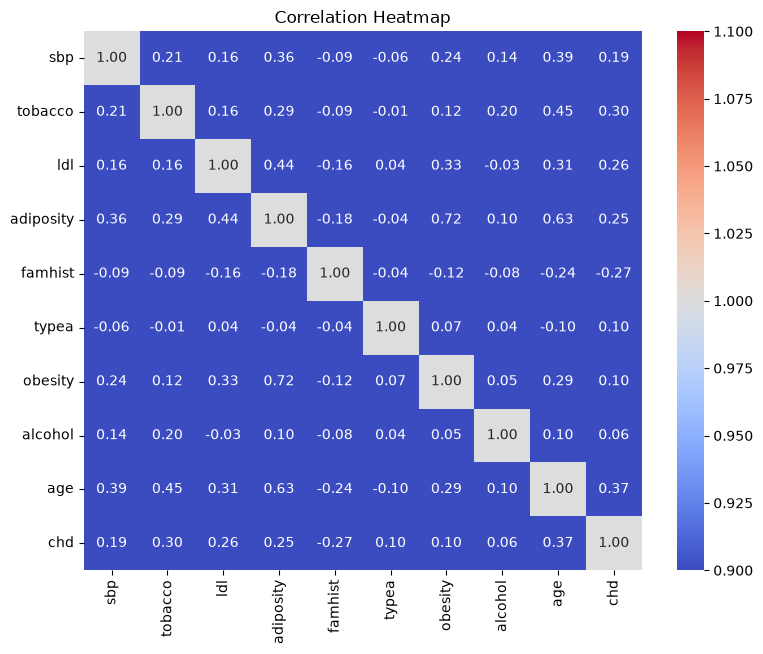

In [19]:
corr_matrix = SAheart_df.corr()
plt.figure(figsize = (9,7))

sn.heatmap(
    corr_matrix,
    annot = True,
    cmap = 'coolwarm',
    vmin = 1,
    vmax = 1,
    fmt = '.2f'
)

plt.title('Correlation Heatmap')
plt.show()



In [21]:
SAheart_df['chd'].unique()

array([1, 0])

<Axes: xlabel='chd', ylabel='tobacco'>

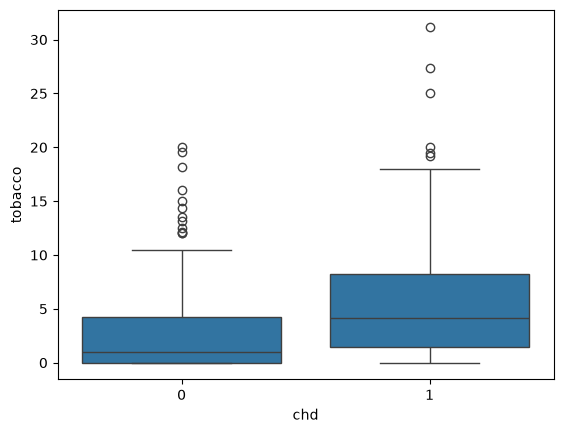

In [22]:
sn.boxplot(data=SAheart_df, x='chd', y= 'tobacco')

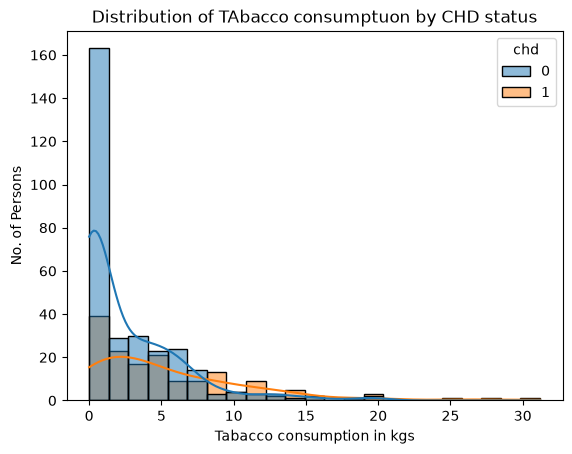

In [29]:
sn.histplot(data = SAheart_df,
            x='tobacco',
            hue='chd',
            kde = True,
            # bins=20
            )
plt.xlabel('Tabacco consumption in kgs')
plt.ylabel('No. of Persons')
plt.title('Distribution of TAbacco consumptuon by CHD status')
plt.show()

In [32]:
bins = [0,15,35,55, float('inf')]
labels = ['young','adults','mid','old']

SAheart_df['agegroup'] = pd.cut(
    SAheart_df['age'],
    bins= bins,
    labels= labels,
    right = False
)


In [35]:

SAheart_df[['age','agegroup']].head()

,age,agegroup
0,52,mid
1,63,old
2,46,mid
3,58,old
4,49,mid


<Axes: xlabel='chd', ylabel='count'>

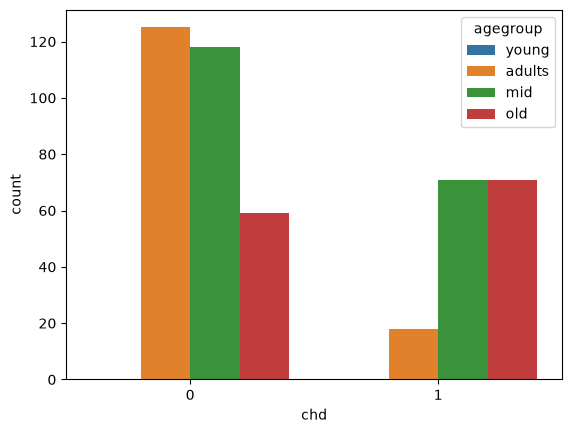

In [36]:
sn.countplot(data=SAheart_df,
             x='chd',
             hue='agegroup'
)
plt.xlabel('CHD occurance ')

In [40]:
chd_cases = (SAheart_df[SAheart_df['chd']==1].groupby('agegroup').size())

<Axes: xlabel='agegroup'>

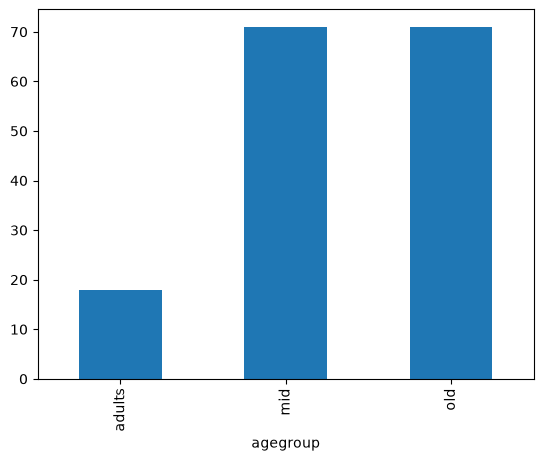

In [45]:
chd_cases.plot(kind='bar')

<Axes: xlabel='agegroup', ylabel='ldl'>

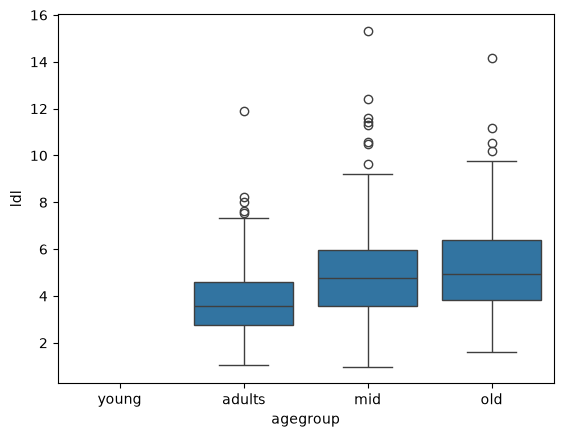

In [46]:
sn.boxplot(data=SAheart_df,
           x='agegroup',
           y='ldl')